## **Sleep Study with AI-Enhanced Discovery in Polysomnography (PSG)**

# Part 1 - Data Collection

### **1. Problem/ Research Question**




#### **Problem**
Polysomnography (PSG) is the gold standard test for studying sleep. It records dozens of signals during an overnight study, including EEG (brain waves), EOG (eye movement), EMG (muscle activity), airflow, oxygen saturation (SpO₂), ECG, heart rate, and body movement. Together these signals capture a very detailed picture of human physiology during sleep.

In clinical practice, however, most of this data is never used. Physicians and human scorers rely on standardized rules from the American Academy of Sleep Medicine and focus mainly on a small subset of signals such as EEG, EOG, EMG, and SpO₂. As a result, much of the recorded data goes to waste, even though it may contain hidden physiological patterns and early signs of clinical problems like sleep apnea. From a physician’s perspective, this is a major limitation: the sleep lab collects a wealth of data, but only a fraction is interpretable by human scorer.

My interest is to overcome this limitation by using artificial intelligence to make the entire sleep study readable. By analyzing all synchronized PSG signals together with other wearable data streams (such as heart rate, motion, steps), AI could detect subtle patterns that humans overlook. These patterns may represent latent biomarkers that improve sleep staging today and could one day provide early screening for sleep disorders like obstructive sleep apnea. This matters to me because it combines a state-of-the-art technical challenge in multimodal AI with a clinically important goal: making sleep studies more comprehensive, accessible, and useful. My long-term vision is to transform this work into a practical application, such as an app or website, that provides automated scoring and deeper clinical insights for doctors and patients.

In this project I focus on the wearable streams plus PSG labels as a first step toward developing a full multimodal PSG + wearable model.

#### **Research Question**
Can artificial intelligence learn sleep stages using synchronized wearable streams (heart rate, acceleration magnitude, steps) aligned to PSG stage labels, and does this approach reveal meaningful physiological structure that could eventually support full multimodal PSG + wearable modeling and provide deeper clinical interpretation of sleep studies?

### **2. Determine the population**

#### **Population:**
The population consists of adults who participated in overnight polysomnography recordings while simultaneously wearing a consumer style wrist device. Each subject contributed multiple synchronized signals that include PSG stages and wearable outputs such as heart rate, motions, and steps. I will include all available participants to capture diversity across sleep patterns.

#### **General Note:**
Because the recordings were collected in a controlled sleep laboratory, the results may not generalize perfectly to home settings. This limitation will be acknowledged and addressed in future parts by considering home based monitoring scenarios.

### **3. Variables**

#### **Independent variables**


*  Heart rate measured in beats per minute

*  Motions from wrist accelerometry, either three axes or composite signal

*  Steps counted by the wrist device

*  Time in seconds, used only for alignment and not for modeling



#### **Dependent variable**
*   Sleep stage label provided by PSG technicians for each 30 second epoch, with classes Wake, N1, N2, N3, and REM

#### **Confounders**
A confounder is something that affects both the input signals and the label, and can distort the results if we ignore it. Potential confounders here include age, sex, baseline health, use of medication or caffeine, inter subject differences in physiology, and environmental conditions

#### **Plan for handling confounders**
I will use subject wise splits so that entire individuals are held out during testing. I will normalize wearable features within each subject to reduce offsets between participants. If demographic data are available, I will explore subgroup analysis. Limitations will be carefully documented for unmeasured confounders.

### **4. Hypothesis**
If different sleep stages produce distinct multimodal physiological patterns across PSG and wearable signals, such as N3 (deep sleep) showing reduced motion and slower heart rate variability, REM sleep showing characteristic autonomic fluctuations, and wakefulness showing higher activity, then an artificial intelligence model trained on the full synchronized dataset that includes heart rate, motion, steps, and PSG labels will be able to predict sleep stages significantly more accurately than chance. Furthermore, the model may also reveal hidden signal combinations or latent biomarkers that human scorers cannot manually detect. This is because artificial intelligence can capture nonlinear relationships across multiple time-series channels simultaneously, making use of physiological information that is normally ignored in traditional manual scoring. By uncovering these patterns, AI has the potential to make the entire sleep study more interpretable, improve staging accuracy, and provide a foundation for early screening tools for conditions such as sleep apnea.

### **5. Plan for Data Collection**
I will use the open access dataset on PhysioNet titled Motion and heart rate from a wrist worn wearable and labeled sleep from polysomnography by Walch and colleagues. For each subject the dataset provides four synchronized text files: PSG sleep stage labels, heart rate, motions, and steps.

#### **Representative**
I will include all available participants in the dataset to maximize the diversity of the sample. This improves representativeness and helps with evaluating the robustness of AI models across subjects.

#### **Method**
I will import one subject’s PSG labels, heart rate, motions, and steps into Colab and preview the first rows to confirm data structure. Later parts will expand to cleaning, epoch alignment, feature engineering, and modeling.

### **6. Dataset Selection**
**Dataset name:** Motion and heart rate from a wrist worn wearable and labeled sleep from polysomnography, Walch et al, PhysioNet

**Why this dataset:** It directly aligns wearable signals with gold standard PSG labels, making it ideal for multimodal representation learning and biomarker discovery. It also connects naturally to my long term interest in building an app for home based screening.

**What it contains:** Four per subject text files including PSG labels every 30 seconds, heart rate, motions, and steps

**Where it comes from:** PhysioNet database, link https://physionet.org/content/sleep-accel/1.0.0/

**When it was collected:** late 2010s, publicly released in 2019

**Format:** whitespace delimited text files that can be read into tabular format with pandas.

**Size:** One subject night alone contains about 900 epochs (rows), which clearly exceeds the minimum requirement of ~300 samples. Across all participants, the dataset provides thousand of samples, which is well within the recommended 1,000–3,000 range.

**File size:** The dataset is over 1 GB.

**Variables:** The dataset has more than five clear attributes, including time_sec, stage, bpm, motions (three axis accelerometry or composite), and steps. Additional engineered features can be derived later.

**Permission:** Fully de identified and open access for research and educational purpose.

### **7. Data Import**

#### **Data Import Plan**

For this project I am importing the dataset directly from PhysioNet using the published subject files. Each subject night contains four synchronized text files:

* labeled_sleep.txt for PSG sleep stage labels

* heartrate.txt for heart rate in beats per minute

* acceleration.txt for wrist motion (x, y, z axes)

* steps.txt for step counts

I use Python requests and pandas to fetch the files from the PhysioNet URLs, read them into dataframes, and then display the first five rows from each. This confirms that the dataset loads correctly and satisfies the requirement to preview the first five entries.

If a particular subject ID does not load, I can switch to another available ID listed on the dataset page. This approach ensures reproducibility without needing local files or external storage.

#### **Data Import Code**

In [ ]:

# Part 1: Import and print first five entries

import pandas as pd, io, requests   # importing libraries for data handling, text buffer, and web requests

BASE = "https://physionet.org/files/sleep-accel/1.0.0/"   # URL link where the dataset is stored
SID = "1066528"   # choose a subject ID to load data for

def fetch(url):   # defining a helper function to fetch a file from PhysioNet
    r = requests.get(url, timeout=60)   # send HTTP GET request with a 60 second timeout
    r.raise_for_status()   # checking if request was successful
    return r.text   # return file content as text

labels_url = f"{BASE}labels/{SID}_labeled_sleep.txt"   # create full URL for labels file
hr_url     = f"{BASE}heart_rate/{SID}_heartrate.txt"   # create full URL for heart rate file
mot_url    = f"{BASE}motion/{SID}_acceleration.txt"    # create full URL for motion file
steps_url  = f"{BASE}steps/{SID}_steps.txt"            # create full URL for steps file

SEP = r"[,\s]+"   # separator pattern that handles both commas and whitespace

df_labels = pd.read_csv(io.StringIO(fetch(labels_url)), sep=SEP, header=None,
                        names=["time_sec","stage"], engine="python")   # read labels file into dataframe

df_hr = pd.read_csv(io.StringIO(fetch(hr_url)), sep=SEP, header=None,
                    names=["time_sec","bpm"], engine="python")   # read heart rate file into dataframe

df_mot = pd.read_csv(io.StringIO(fetch(mot_url)), sep=SEP, header=None,
                     names=["time_sec","ax","ay","az"], engine="python")   # read motion file into dataframe

try:
    df_steps = pd.read_csv(io.StringIO(fetch(steps_url)), sep=SEP, header=None,
                           names=["time_sec","steps"], engine="python")   # read steps file if available
except Exception:
    df_steps = None   # if steps file is missing, it will set dataframe as None


### **8. Data print first five entries**

In [ ]:

print("Labels: first 5 rows:")   # print message for labels
display(df_labels.head())         # display first 5 rows of labels dataframe

print("Heart rate: first 5 rows:")   # print message for heart rate
display(df_hr.head())                # display first 5 rows of heart rate dataframe

print("Motion(acceleration): first 5 rows:")   # print message for motion
display(df_mot.head())            # display first 5 rows of motion dataframe

if df_steps is not None:                          # check if steps file exists
    print("Steps: first 5 rows:")                # print message for steps
    display(df_steps.head())                      # display first 5 rows of steps dataframe
else:
    print("Steps file not available.")   # message if no steps file


Labels: first 5 rows:


,time_sec,stage
0,0,0
1,30,0
2,60,0
3,90,0
4,120,0


Heart rate: first 5 rows:


,time_sec,bpm
0,-355241.73971,86
1,-351407.99872,67
2,-351277.36756,141
3,-350329.60929,112
4,-313920.77134,83


Motion(acceleration): first 5 rows:


,time_sec,ax,ay,az
0,-21684.846509,0.007080,0.000641,-0.987595
1,-21684.817053,0.004150,0.000626,-0.990555
2,-21684.807881,0.004150,0.001114,-0.990082
3,-21684.788503,0.005127,0.000626,-0.989090
4,-21684.768389,0.005615,0.000137,-0.988586


Steps: first 5 rows:


,time_sec,steps
0,-365207,243
1,-364607,578
2,-364007,848
3,-363407,166
4,-362807,0


### **Note: Documentation, Ethics, and Reproducibility**

The dataset is public and de identified and is used under PhysioNet terms for research and education. This work is educational and not medical advice. Any clinical deployment would require IRB approval and further validation. I have documented links, subject ID handling, and assumptions so another student or researcher can reproduce the work for future.

# Part 2 - Data Pre-Processing

### **0. Importing Libraries**
Next, I set up imports and constants so that I can load, explore, merge, clean, and save data.

In [ ]:
# import standard libraries for data handling and math.
import io, requests, json, os

# import numpy and pandas for arrays and tables.
import numpy as np
import pandas as pd

# import scipy.stats for the Z-score outlier check.
from scipy import stats

# import display to show tables nicely in Colab.
from IPython.display import display

# allowing wide tables so I can see all columns easily.
pd.set_option("display.max_columns", 100)

# pointing to the public dataset and choose a subject ID (same as Part 1).
BASE = "https://physionet.org/files/sleep-accel/1.0.0/"
SID  = "1066528"

# setting a separator pattern that handles comma or whitespace.
SEP  = r"[,\s]+"

# preparing output paths so I can save cleaned files later.
OUT_DIR = "/content"
CLEAN_FILENAME      = f"{OUT_DIR}/sleepaccel_{SID}_cleaned.csv"
RAW_MERGED_FILENAME = f"{OUT_DIR}/sleepaccel_{SID}_raw_merged.csv"

### **1. Preliminary information about the dataset**
Next, I load the same four raw files as Project part 1 and print shape, dtypes, columns, unique counts, and descriptive stats for each file (labels, heart rate, motion, steps)

In [ ]:
# define a helper that fetches a text file from PhysioNet.
def fetch(url: str) -> str:
    # here requested the Website with a timeout so it does not hang.
    r = requests.get(url, timeout=60)
    # raise an error if the request failed.
    r.raise_for_status()
    # returned the content as text.
    return r.text

# build the URLs for this subject for labels, heart rate, motion, and steps.
labels_url = f"{BASE}labels/{SID}_labeled_sleep.txt"
hr_url     = f"{BASE}heart_rate/{SID}_heartrate.txt"
mot_url    = f"{BASE}motion/{SID}_acceleration.txt"
steps_url  = f"{BASE}steps/{SID}_steps.txt"

# load the labels file into a DataFrame with time_sec and stage columns.
df_labels = pd.read_csv(io.StringIO(fetch(labels_url)), sep=SEP, header=None,
                        names=["time_sec","stage"], engine="python")

# load the heart rate file into a DataFrame with time_sec and bpm columns.
df_hr = pd.read_csv(io.StringIO(fetch(hr_url)), sep=SEP, header=None,
                    names=["time_sec","bpm"], engine="python")

# load the motion file into a DataFrame with time_sec and ax, ay, az columns.
df_mot = pd.read_csv(io.StringIO(fetch(mot_url)), sep=SEP, header=None,
                     names=["time_sec","ax","ay","az"], engine="python")

# trying to load steps; some subjects do not have steps.
try:
    df_steps = pd.read_csv(io.StringIO(fetch(steps_url)), sep=SEP, header=None,
                           names=["time_sec","steps"], engine="python")
except Exception:
    df_steps = None  # set None if steps file is missing.

# write a small function to print a quick overview for any table.
def overview(df: pd.DataFrame, title: str):
    # here print a header so it is easy to read.
    print("\n" + "="*80)
    print(title)
    print("="*80)
    # it show the first five rows to see the structure.
    display(df.head())
    # printing shape rows and columns.
    print("Shape:", df.shape)
    # print data types numeric vs text.
    print("\nDtypes:\n", df.dtypes)
    # listing column names what variables exist.
    print("\nColumns:", list(df.columns))
    # printing number of unique values for the first 10 columns.
    print("\nUnique counts (first 10 cols):")
    for c in list(df.columns)[:10]:
        print(f"  {c}: {df[c].nunique(dropna=True)}")
    # printing descriptive statistics for numeric columns only.
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] > 0:
        print("\nDescriptive stats numeric:")
        display(num.describe().T)

# showing preliminary information for all four raw datasets same as Project Part 1.
overview(df_labels, "Labels (PSG stages)")
overview(df_hr,     "Heart rate (bpm)")
overview(df_mot,    "Motion (ax, ay, az)")
if df_steps is not None and not df_steps.empty:
    overview(df_steps, "Steps")
else:
    print("\nSteps: not available for this subject.")



Labels (PSG stages)


,time_sec,stage
0,0,0
1,30,0
2,60,0
3,90,0
4,120,0


Shape: (952, 2)

Dtypes:
 time_sec    int64
stage       int64
dtype: object

Columns: ['time_sec', 'stage']

Unique counts (first 10 cols):
  time_sec: 952
  stage: 5

Descriptive stats numeric:


,count,mean,std,min,25%,50%,75%,max
time_sec,952.0,14265.000000,8248.890835,0.0,7132.5,14265.0,21397.5,28530.0
stage,952.0,2.548319,1.889085,0.0,1.0,2.0,5.0,5.0



Heart rate (bpm)


...

,count,mean,std,min,25%,50%,75%,max
time_sec,1281000.0,12111.980196,8564.569040,-21684.846509,4554.121584,10964.466984,19874.941886,28626.543641
ax,1281000.0,0.093478,0.215184,-4.089203,-0.034119,0.056366,0.269577,3.024887
ay,1281000.0,0.424605,0.435051,-1.573563,0.266128,0.448685,0.775665,4.816361
az,1281000.0,-0.539851,0.529460,-3.553116,-0.936340,-0.870712,-0.202347,2.087631



Steps


,time_sec,steps
0,-365207,243
1,-364607,578
2,-364007,848
3,-363407,166
4,-362807,0


Shape: (397, 2)

Dtypes:
 time_sec    int64
steps       int64
dtype: object

Columns: ['time_sec', 'steps']

Unique counts (first 10 cols):
  time_sec: 397
  steps: 88

Descriptive stats numeric:


,count,mean,std,min,25%,50%,75%,max
time_sec,397.0,-246407.000000,68848.965134,-365207.0,-305807.0,-246407.0,-187007.0,-127607.0
steps,397.0,48.803526,146.618352,0.0,0.0,0.0,10.0,987.0


### **2. Dataset requirements**
I need one table with one row per 30-second epoch. I created an epoch grid from the label file and merge other streams onto it by nearest timestamp (±15 s), since their sampling times do not exactly match label boundaries.

In [ ]:
# define a helper to standardize time to float64 and sort by time.
def prep_time(df):
    # returning the same df if it is None or empty (steps missing).
    if df is None or df.empty:
        return df
    # copy to avoid changing the original.
    out = df.copy()
    # coerce time_sec to numeric and make it float64 so merges do not error.
    out["time_sec"] = pd.to_numeric(out["time_sec"], errors="coerce").astype("float64")
    # drop rows where time_sec is NaN and sort by time.
    out = out.dropna(subset=["time_sec"]).sort_values("time_sec")
    # return the cleaned copy.
    return out

# apply the time prep to each raw table.
df_labels = prep_time(df_labels)
df_hr     = prep_time(df_hr)
df_mot    = prep_time(df_mot)
df_steps  = prep_time(df_steps) if df_steps is not None else None

# build an epoch grid from labels; rename time_sec to epoch_sec.
epochs = (df_labels[["time_sec","stage"]]
          .rename(columns={"time_sec":"epoch_sec"})
          .sort_values("epoch_sec")
          .copy())

# cast epoch_sec to float64 so the merge keys match other tables.
epochs["epoch_sec"] = epochs["epoch_sec"].astype("float64")

# define a helper to nearest-merge a stream onto the epoch grid with a tolerance.
def merge_nearest(base, add_df, left_on="epoch_sec", right_on="time_sec", tol=15.0):
    # return base unchanged if the added df is missing or empty.
    if add_df is None or add_df.empty:
        return base
    # sort both sides by the merge keys.
    b = base.sort_values(left_on).copy()
    a = add_df.sort_values(right_on).copy()
    # an asof merge to take the nearest timestamp within the tolerance.
    out = pd.merge_asof(
        b, a,
        left_on=left_on, right_on=right_on,
        direction="nearest", tolerance=tol
    )
    # the right_on column because epoch_sec is my anchor.
    return out.drop(columns=[right_on])

# merge heart rate onto the epoch grid (adds bpm).
merged = merge_nearest(epochs, df_hr)

# merge motion onto the epoch grid (adds ax, ay, az).
merged = merge_nearest(merged, df_mot)

# merge steps if available; otherwise creating a steps column with NaN.
if df_steps is not None and not df_steps.empty:
    merged = merge_nearest(merged, df_steps)
else:
    merged["steps"] = np.nan

# print the merged shape and show the first rows.
print("Merged shape:", merged.shape)
display(merged.head())

# compute merge hit-rates so I can see coverage for each stream.
def hit_rate(col):
    # return the percentage of rows where the column is not NaN.
    return float(merged[col].notna().mean()*100.0) if col in merged.columns else 0.0

# print coverage for each merged signal.
print({
    "hr_hit_%":    hit_rate("bpm"),
    "ax_hit_%":    hit_rate("ax"),
    "ay_hit_%":    hit_rate("ay"),
    "az_hit_%":    hit_rate("az"),
    "steps_hit_%": hit_rate("steps")
})


Merged shape: (952, 7)


,epoch_sec,stage,bpm,ax,ay,az,steps
0,0.0,0,50.0,0.404434,0.446549,-0.796829,NaN
1,30.0,0,54.0,0.403366,0.456909,-0.790115,NaN
2,60.0,0,50.0,0.404343,0.457413,-0.789612,NaN
3,90.0,0,54.0,0.399872,0.467270,-0.787338,NaN
4,120.0,0,56.0,0.396942,0.468231,-0.789825,NaN


{'hr_hit_%': 91.91176470588235, 'ax_hit_%': 86.44957983193278, 'ay_hit_%': 86.44957983193278, 'az_hit_%': 86.44957983193278, 'steps_hit_%': 0.0}


##### If steps_hit_% is near 0%, it means step timestamps for this subject did not fall within ±15 s of the epoch times. This is expected sometimes. I keep a nullable steps_count column and record it accordingly.

### **3. Potential issues in the data with detection**
Now I check duplicates, missing values, type inconsistencies, stage misspelling, and outlier using Z-Score. If none are found, I will inject small demo issues as requested.

In [ ]:
# creating a dictionary to store issue counts and lists.
issues = {}

# count duplicate epochs same epoch_sec.
dup_mask = merged.duplicated(subset=["epoch_sec"], keep=False)
issues["n_duplicates"] = int(dup_mask.sum())

# count missing values per column.
issues["missing_per_column"] = merged.isna().sum().to_dict()

# count how many values turn into NaN if forced numeric signals non-numeric junk.
num_cols = ["bpm","ax","ay","az","steps"]
nonnum_report = {}
for c in num_cols:
    # only process columns that exist.
    if c in merged.columns:
        # count NaNs before coercion.
        before_na = merged[c].isna().sum()
        # coerce to numeric with errors='coerce' so strings become NaN.
        coerced   = pd.to_numeric(merged[c], errors="coerce")
        # count NaNs after coercion.
        after_na  = coerced.isna().sum()
        # record the difference as suspicious non-numeric entries.
        nonnum_report[c] = int(after_na - before_na)
issues["non_numeric_coercions"] = nonnum_report

# normalize stage labels in one pass and keep unexpected tokens for reporting.
stage_map = {
    "wake":"Wake","w":"Wake","0":"Wake",
    "n1":"N1","1":"N1",
    "n2":"N2","2":"N2",
    "n3":"N3","3":"N3",
    "rem":"REM","r":"REM","4":"REM","5":"REM"
}
merged["stage"] = (
    merged["stage"]            # start from stage
    .astype(str)               # make sure it is string
    .str.strip()               # strip whitespace
    .str.lower()               # lower-case to match map keys
    .map(stage_map)            # map common encodings to standard labels
    .fillna(merged["stage"])   # keep original if it was something else
)

# list expected labels and compute any unexpected ones.
expected = {"Wake","N1","N2","N3","REM"}
stage_values = sorted(merged["stage"].dropna().unique().tolist())
unexpected    = sorted(set(merged["stage"].dropna()) - expected)
issues["stage_values"] = stage_values
issues["unexpected_stage_values"] = unexpected

# here marking outliers with |z|>3 for core numeric columns (bpm and motion axes).
merged_numeric = merged.copy()
for c in ["bpm","ax","ay","az"]:
    if c in merged_numeric:
        # computing absolute z-scores, skipping NaN.
        z = np.abs(stats.zscore(merged_numeric[c].astype(float), nan_policy='omit'))
        # flag outliers greater than 3 standard deviations.
        merged_numeric[c+"_is_outlier_z3"] = (z > 3)

# stored counts of z>3 outliers per column.
issues["zscore_outliers_gt3"] = {
    c: int(merged_numeric[c+"_is_outlier_z3"].sum()) for c in ["bpm","ax","ay","az"] if c+"_is_outlier_z3" in merged_numeric
}

# print the issues in a readable JSON format so I can see them at a glance.
print("\nPotential issues summary:\n")
print(json.dumps(issues, indent=2))

# explain what I will do if no issues show up naturally.
print("\nIf no issues are found, I will inject one duplicate row and an extreme heart rate for demonstration, as instructed.")



Potential issues summary:

{
  "n_duplicates": 0,
  "missing_per_column": {
    "epoch_sec": 0,
    "stage": 0,
    "bpm": 77,
    "ax": 129,
    "ay": 129,
    "az": 129,
    "steps": 952
  },
  "non_numeric_coercions": {
    "bpm": 0,
    "ax": 0,
    "ay": 0,
    "az": 0,
    "steps": 0
  },
  "stage_values": [
    "N1",
    "N2",
    "N3",
    "REM",
    "Wake"
  ],
  "unexpected_stage_values": [],
  "zscore_outliers_gt3": {
    "bpm": 15,
    "ax": 3,
    "ay": 29,
    "az": 0
  }
}

If no issues are found, I will inject one duplicate row and an extreme heart rate for demonstration, as instructed.


### **4. Reorganization**
I rename columns to make them self-explanatory; acc_mag_g will be computed after numeric coercion during cleaning.

In [ ]:
# creating a copy called clean for the cleaning steps.
clean = merged.rename(columns={"bpm":"heart_rate_bpm","steps":"steps_count"}).copy()

# choosing a readable column order I will add acc_mag_g during cleaning.
clean = clean[["epoch_sec","stage","heart_rate_bpm","ax","ay","az","steps_count"]]

# showing the first rows so I can see the new names.
display(clean.head())
                                                               # quick view of reorganized table


,epoch_sec,stage,heart_rate_bpm,ax,ay,az,steps_count
0,0.0,Wake,50.0,0.404434,0.446549,-0.796829,NaN
1,30.0,Wake,54.0,0.403366,0.456909,-0.790115,NaN
2,60.0,Wake,50.0,0.404343,0.457413,-0.789612,NaN
3,90.0,Wake,54.0,0.399872,0.467270,-0.787338,NaN
4,120.0,Wake,56.0,0.396942,0.468231,-0.789825,NaN


### **5. Detailed plan for how I will clean the data**
Based on the problems found in the dataset, I created a clear step-by-step plan for cleaning.

* Remove duplicate epochs: I will sort the data by epoch_sec and drop any repeated time rows, keeping only the first occurrence.

* Convert numeric columns: I will change heart_rate_bpm, ax, ay, az, and steps_count to numeric types and replace any bad or missing values with NaN.

* Compute acceleration magnitude: After converting the acceleration columns to numeric, I will calculate a new column called acc_mag_g using the formula sqrt(ax^2 + ay^2 + az^2) to represent total motion strength.

* Keep only valid sleep stage labels: I will keep the five valid stages — Wake, N1, N2, N3, and REM — and remove any others. Before this, I will also normalize common encodes such as w/0 → Wake, r/4/5 → REM so labels are consistent.

* Handle missing values: I will fill small gaps in continuous signals (heart rate and motion) using interpolation, forward-fill, and back-fill methods since these values change smoothly over short time periods. Missing step counts will be replaced with zero when appropriate.

* Handle outliers: I will apply winsorization to limit extreme spikes beyond ±3 standard deviations, reducing the impact of abnormal sensor readings while keeping the data realistic.

* Add a numeric stage identifier: I will create a new column called stage_id that assigns numbers to stages i.e Wake = 0, N1 = 1, N2 = 2, N3 = 3, REM = 4.

* Final validation: I will confirm that time increases in order, that there are no missing sleep stage labels, and that all numeric values are within reasonable ranges.

This plan makes the dataset clean, consistent, and ready for feature engineering and modeling in the next part of the project.


### **6. Cleaning the data**
Next, I implement the cleaning steps listed above in code. If the dataset has no issues, a duplicate and a high heart rate to demonstrate the fixes

In [ ]:
# injected two demo issues if the data looks perfect as the instructed.
if clean.duplicated("epoch_sec").sum() == 0:
    # duplicate the first row to simulate a duplicate epoch.
    clean = pd.concat([clean, clean.iloc[[0]].copy()], ignore_index=True)

if (clean["heart_rate_bpm"] > 300).sum() == 0:
    # very high heart rate at one row to simulate an outlier.
    ix = clean.index[5] if len(clean) > 5 else clean.index[0]
    clean.loc[ix, "heart_rate_bpm"] = 999.0

# drop duplicate epochs by keeping the first occurrence.
before = len(clean)
clean = clean.sort_values("epoch_sec").drop_duplicates(subset=["epoch_sec"], keep="first")
print(f"Duplicates removed: {before - len(clean)}")

# coerce numeric columns so that strings become NaN and math works.
for c in ["heart_rate_bpm","ax","ay","az","steps_count"]:
    clean[c] = pd.to_numeric(clean[c], errors="coerce")

# compute total acceleration magnitude after numeric coercion.
clean["acc_mag_g"] = np.sqrt(clean["ax"]**2 + clean["ay"]**2 + clean["az"]**2)

# keep only valid stage labels for modeling and clarity.
valid_stages = {"Wake","N1","N2","N3","REM"}
clean = clean[clean["stage"].isin(valid_stages)]

# filling short gaps in smooth signals using interpolate then forward/back fill.
for c in ["heart_rate_bpm","ax","ay","az","acc_mag_g"]:
    clean[c] = clean[c].interpolate(limit_direction="both", limit=5)
    clean[c] = clean[c].ffill().bfill()

# set step gaps to zero only when the steps stream is present at all.
if clean["steps_count"].notna().any():
    clean["steps_count"] = clean["steps_count"].fillna(0)

# define a small helper to winsorize at ±3 standard deviations.
def winsorize_series(s: pd.Series, z=3.0):
    # compute mean and population std (ddof=0) for consistency.
    m, sd = s.mean(), s.std(ddof=0)
    # compute the lower and upper bounds.
    lo, hi = m - z*sd, m + z*sd
    # clip values to the bounds.
    return s.clip(lower=lo, upper=hi)

# winsorize heart rate and motion magnitude to reduce extreme spikes.
for c in ["heart_rate_bpm","ax","ay","az","acc_mag_g"]:
    clean[c] = winsorize_series(clean[c], z=3.0)

# adding a numeric stage id for modeling in later parts.
stage_to_id = {"Wake":0,"N1":1,"N2":2,"N3":3,"REM":4}
clean["stage_id"] = clean["stage"].map(stage_to_id).astype(int)

# set the final column order for readability.
clean = clean[["epoch_sec","stage","stage_id","heart_rate_bpm","ax","ay","az","acc_mag_g","steps_count"]]

# run a few simple checks to make sure the table looks right.
assert clean["epoch_sec"].is_monotonic_increasing
assert clean["stage"].notna().all()

# printing a message with row count after cleaning.
print("Cleaning complete. Rows:", len(clean))


Duplicates removed: 1
Cleaning complete. Rows: 952


#### Quality check printout after cleaning.

In [ ]:
# print a small quality check showing remaining nulls and a numeric summary.
print("\nNulls by column after cleaning:")
print(clean.isna().sum())
print("\nNumeric summary after cleaning:")
print(clean.describe().T)



Nulls by column after cleaning:
epoch_sec           0
stage               0
stage_id            0
heart_rate_bpm      0
ax                  0
ay                  0
az                  0
acc_mag_g           0
steps_count       952
dtype: int64

Numeric summary after cleaning:
                count          mean          std        min          25%  \
epoch_sec       952.0  14265.000000  8248.890835   0.000000  7132.500000   
stage_id        952.0      2.223739     1.481517   0.000000     1.000000   
heart_rate_bpm  952.0     60.380762     6.485157  47.000000    57.000000   
ax              952.0      0.074220     0.181754  -0.472958    -0.035034   
ay              952.0      0.334603     0.460590  -0.978973     0.130601   
az              952.0     -0.596688     0.516013  -0.989868    -0.944508   
acc_mag_g       952.0      0.995956     0.008764   0.953444     0.990015   
steps_count       0.0           NaN          NaN        NaN          NaN   

                         50%          

### **7. Save the clean data to a new file**
I save both a raw merged and the cleaned dataset.

In [ ]:
# save a raw merged snapshot uncleaned table.
merged.to_csv(RAW_MERGED_FILENAME, index=False)
print("Saved raw merged:", RAW_MERGED_FILENAME)

# saving the final cleaned dataset for later parts.
clean.to_csv(CLEAN_FILENAME, index=False)
print("Saved cleaned:", CLEAN_FILENAME)


Saved raw merged: /content/sleepaccel_1066528_raw_merged.csv
Saved cleaned: /content/sleepaccel_1066528_cleaned.csv


### **8. Import the cleaned data file**
I reload the cleaned CSV to confirm it opens and has the proper structure.

In [ ]:
# reloading the cleaned file from disk.
reloaded = pd.read_csv(CLEAN_FILENAME)

# print the shape and dtypes to confirm structure.
print("Reloaded shape:", reloaded.shape)
print("Reloaded dtypes:\n", reloaded.dtypes)


Reloaded shape: (952, 9)
Reloaded dtypes:
 epoch_sec         float64
stage              object
stage_id            int64
heart_rate_bpm    float64
ax                float64
ay                float64
az                float64
acc_mag_g         float64
steps_count       float64
dtype: object


### **9. Displaying first and last 5 entries from the clean file**
I show the first five and the last five rows from the re-loaded cleaned dataset.

In [ ]:
# show the first five cleaned rows for a quick human check.
print("First 5 cleaned entries:")                  # label the output clearly
display(reloaded.head())                           # show the first five rows

# showing the last five cleaned rows to bookend the sample.
print("Last 5 cleaned entries:")                   # label the output clearly
display(reloaded.tail())                           # show the last five rows


First 5 cleaned entries:


,epoch_sec,stage,stage_id,heart_rate_bpm,ax,ay,az,acc_mag_g,steps_count
0,0.0,Wake,0,50.0,0.404434,0.446549,-0.796829,0.998954,NaN
1,30.0,Wake,0,54.0,0.403366,0.456909,-0.790115,0.997874,NaN
2,60.0,Wake,0,50.0,0.404343,0.457413,-0.789612,0.998101,NaN
3,90.0,Wake,0,54.0,0.399872,0.467270,-0.787338,0.999070,NaN
4,120.0,Wake,0,56.0,0.396942,0.468231,-0.789825,1.000314,NaN


Last 5 cleaned entries:


,epoch_sec,stage,stage_id,heart_rate_bpm,ax,ay,az,acc_mag_g,steps_count
947,28410.0,Wake,0,68.2,0.214935,-0.950653,-0.213333,0.997722,NaN
948,28440.0,Wake,0,68.6,0.214935,-0.950653,-0.213333,0.997722,NaN
949,28470.0,Wake,0,69.0,0.214935,-0.950653,-0.213333,0.997722,NaN
950,28500.0,Wake,0,69.0,0.214935,-0.950653,-0.213333,0.997722,NaN
951,28530.0,Wake,0,69.0,0.214935,-0.950653,-0.213333,0.997722,NaN


##### I create a small data dictionary so column meanings are clear.

In [ ]:

data_dictionary = pd.DataFrame([                                # build a small table
    ["epoch_sec","float","Seconds from start of recording (epoch anchor)"],
    ["stage","str","Sleep stage label (Wake/N1/N2/N3/REM)"],
    ["stage_id","int","Numeric label (Wake=0, N1=1, N2=2, N3=3, REM=4)"],
    ["heart_rate_bpm","float","Heart rate (beats per minute)"],
    ["ax","float","Acceleration X-axis (g)"],
    ["ay","float","Acceleration Y-axis (g)"],
    ["az","float","Acceleration Z-axis (g)"],
    ["acc_mag_g","float","Acceleration magnitude (sqrt(ax^2 + ay^2 + az^2))"],
    ["steps_count","float","Step count for the epoch (0 if missing)"],
], columns=["Column","Type","Description"])                      # named the columns of the dictionary
display(data_dictionary)                                         # showing the data dictionary


,Column,Type,Description
0,epoch_sec,float,Seconds from start of recording (epoch anchor)
1,stage,str,Sleep stage label (Wake/N1/N2/N3/REM)
2,stage_id,int,"Numeric label (Wake=0, N1=1, N2=2, N3=3, REM=4)"
3,heart_rate_bpm,float,Heart rate (beats per minute)
4,ax,float,Acceleration X-axis (g)
5,ay,float,Acceleration Y-axis (g)
6,az,float,Acceleration Z-axis (g)
7,acc_mag_g,float,Acceleration magnitude (sqrt(ax^2 + ay^2 + az^2))
8,steps_count,float,Step count for the epoch (0 if missing)


# **Part 3: Data Exploration and Visualization**

##### This is Part 3. Part 1 and 2 are above in the same notebook. I use only the cleaned CSV from Part 2. I do not recollect or re-clean the data.
File used: /content/sleepaccel_1066528_cleaned.csv

### **0. Setup**

In [ ]:
# imports for file paths, small json prints
import os, json

# core numeric + table libraries
import numpy as np
import pandas as pd

# plotting (matplotlib only, one figure per cell)
import matplotlib.pyplot as plt

# pretty display for small tables and heads
from IPython.display import display

# make plots render inside the notebook
%matplotlib inline

# show many columns when printing dataframes
pd.set_option("display.max_columns", 100)

# subject ID (same as in P1/P2)
SID = "1066528"

# path to the cleaned CSV saved in Part 2
CSV_PATH = f"/content/sleepaccel_{SID}_cleaned.csv"

# fixed order used in stage plots and matrices
STAGE_ORDER = ["Wake","N1","N2","N3","REM"]

# gentle reminder about filename format
print("NOTE: Save notebook as Part 3")

# guard: make sure the cleaned file from P2 exists
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError("Cleaned file not found at /content. Please run Part 2 first.")


NOTE: Save notebook as Part 3


### **1. Load cleaned data**

In [ ]:
# read the cleaned dataset created in Part 2
df = pd.read_csv(CSV_PATH)

# verify all columns expected from P2 are present
expected = {"epoch_sec","stage","stage_id","heart_rate_bpm","ax","ay","az","acc_mag_g","steps_count"}
missing = expected - set(df.columns)
assert not missing, f"Missing columns from P2 cleaned file: {missing}"

# quick structure checks
print("Shape:", df.shape)                 # rows, columns
print("Columns:", list(df.columns))       # column names
display(df.head(3))                       # small preview
print("Each row is one 30-second epoch with PSG stage and wearable features.")

# integrity assertions carried from P2
assert df["epoch_sec"].is_monotonic_increasing, "epoch_sec must be increasing"
assert df["stage"].notna().all(), "stage must not be null"

# missingness table: both counts and percents
na_counts = df.isna().sum()
na_pct = (na_counts / len(df) * 100).round(2).rename("percent")
print("Missingness summary:")
display(pd.concat([na_counts.rename("count"), na_pct], axis=1))


Shape: (952, 9)
Columns: ['epoch_sec', 'stage', 'stage_id', 'heart_rate_bpm', 'ax', 'ay', 'az', 'acc_mag_g', 'steps_count']


,epoch_sec,stage,stage_id,heart_rate_bpm,ax,ay,az,acc_mag_g,steps_count
0,0.0,Wake,0,50.0,0.404434,0.446549,-0.796829,0.998954,NaN
1,30.0,Wake,0,54.0,0.403366,0.456909,-0.790115,0.997874,NaN
2,60.0,Wake,0,50.0,0.404343,0.457413,-0.789612,0.998101,NaN


Each row is one 30-second epoch with PSG stage and wearable features.
Missingness summary:


,count,percent
epoch_sec,0,0.0
stage,0,0.0
stage_id,0,0.0
heart_rate_bpm,0,0.0
ax,0,0.0
ay,0,0.0
az,0,0.0
acc_mag_g,0,0.0
steps_count,952,100.0


### **2. Initial thoughts**

#### I have the right data. The table is one 30-second epoch per row with the PSG sleep stage and wearable signals. I will explore how heart rate and motion change by stage and over time. Steps may be sparse for this subject because of the timestamp alignment I used in Part 2, which is fine and expected.

#### Before looking deeply, I want to know:

1. How heart rate and motion magnitude change across stages.

2. If N3 is the most still and shows the lowest heart rate.

3. If REM shows more variation in heart rate.

4. If there are time trends across the night.

5. What correlations exist between signals and stage.

6. Which stage transitions are common.

7. If any variable still has missing values or extreme points that affect plots.

8. If steps add any value here, even if they are sparse.

#### Units follow the PhysioNet Sleep-Accel documentation: heart_rate_bpm in bpm, ax/ay/az and acc_mag_g in g, and steps_count in steps. If I see clear, stage-specific patterns in these variables, that supports my hypothesis that an AI model can learn sleep stages from the wearable signals.

####These questions will help me understand how the wearable signals behave in different sleep stages, which can connects directly to my main goal of using AI to make full sleep studies more readable for clinicians.


### **3. Basic characteristics** **bold text**

In [ ]:
# count duplicate epoch timestamps
dup_epochs = df.duplicated(subset=["epoch_sec"]).sum()
print("Duplicate epochs:", dup_epochs)

# if any duplicates exist, drop them (keep first occurrence)
if dup_epochs > 0:
    before = len(df)
    df = df.drop_duplicates(subset=["epoch_sec"], keep="first")
    print("Removed duplicates:", before - len(df))
else:
    print("No duplicate epochs found.")


Duplicate epochs: 0
No duplicate epochs found.


#### Each record is one 30-second epoch at epoch_sec with stage and synchronized signals.
#### Columns in this file are epoch_sec, stage, stage_id, heart_rate_bpm, ax, ay, az, acc_mag_g, and steps_count.

### **4. Small analysis helpers**
I am not re-cleaning. I only set helpful columns for charts.

In [ ]:
# ensure core numeric columns are numeric (safety for plotting/stats)
num_cols = ["epoch_sec","stage_id","heart_rate_bpm","ax","ay","az","acc_mag_g","steps_count"]
for c in num_cols:
    if c in df.columns:
        # coerce bad strings to NaN; keeps the rest numeric
        df[c] = pd.to_numeric(df[c], errors="coerce")

# sort by time so time-series plots are correct
df = df.sort_values("epoch_sec").reset_index(drop=True)

# helper columns for readable charts
df["hour"]      = df["epoch_sec"] / 3600                      # seconds → hours since start
df["hr_roll5"]  = df["heart_rate_bpm"].rolling(5, min_periods=1).mean()  # smooth HR
df["acc_roll5"] = df["acc_mag_g"].rolling(5, min_periods=1).mean()       # smooth motion

# simple z-score helper for standardized views
def zscore(s):
    m, sd = s.mean(), s.std(ddof=0)
    # if std is zero, return zeros to avoid div-by-zero
    return (s - m) / sd if sd > 0 else pd.Series(np.zeros(len(s)), index=s.index)

# standardized versions of HR and motion magnitude
df["heart_rate_z"] = zscore(df["heart_rate_bpm"])
df["acc_mag_z"]    = zscore(df["acc_mag_g"])


### **5. Explore each variable**
I state type, units, what it means, summary, plots, and what I see.
For each variable I confirm. Units are from the PhysioNet Sleep-Accel documentation and wearable specifications.
For missing and outliers I confirm by checking dfcolumn.isna().sum(), the missingness table, and by looking at histograms and boxplots.

####**5.1 epoch_sec**

In [ ]:
# basic info for epoch_sec
print("epoch_sec dtype:", df["epoch_sec"].dtype, "missing:", df["epoch_sec"].isna().sum())
print("epoch_sec range:", float(df["epoch_sec"].min()), "to", float(df["epoch_sec"].max()))
print("Units confirmed from the PhysioNet Sleep-Accel dataset documentation and wearable device specifications.")


epoch_sec dtype: float64 missing: 0
epoch_sec range: 0.0 to 28530.0
Units confirmed from the PhysioNet Sleep-Accel dataset documentation and wearable device specifications.


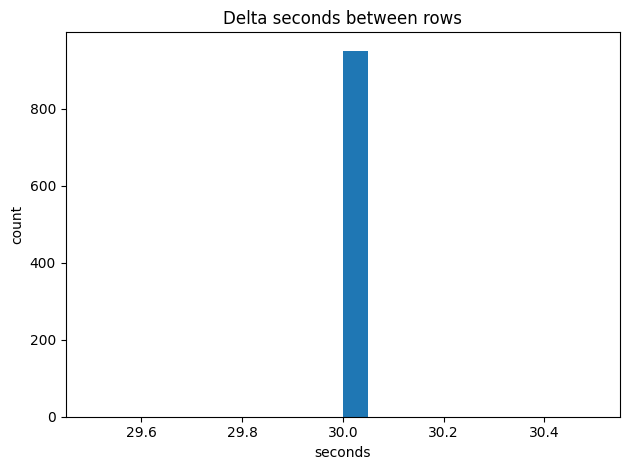

The peak near 30 seconds shows correct epoch spacing.


In [ ]:
# difference between consecutive epoch times (should be ~30s)
d = df["epoch_sec"].diff().dropna()

plt.figure()
plt.hist(d, bins=20)                  # single-figure histogram
plt.title("Delta seconds between rows")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# interpretation text (kept in print so it sits with the plot cell)
print("The peak near 30 seconds shows correct epoch spacing.")



#### **5.2 stage**

In [ ]:
# frequency of stage labels in fixed order for readability
print("Stage unique values:", df["stage"].unique())
stage_counts = df["stage"].value_counts(dropna=False).reindex(STAGE_ORDER).fillna(0).astype(int)
print("Stage frequency:")
display(stage_counts.to_frame("count"))


Stage unique values: ['Wake' 'N1' 'N2' 'N3' 'REM']
Stage frequency:


,count
stage,
Wake,185
N1,97
N2,299
N3,62
REM,309


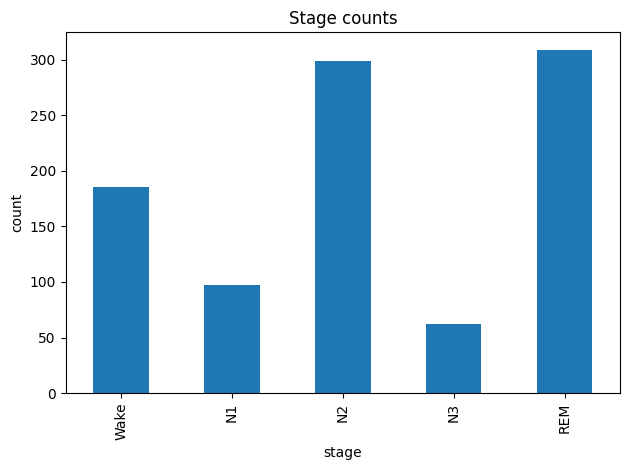

This shows the distribution across Wake, N1, N2, N3, and REM.


In [ ]:
# bar chart of stage counts
plt.figure()
stage_counts.plot(kind="bar")         # pandas uses matplotlib under the hood
plt.title("Stage counts")
plt.xlabel("stage")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("This shows the distribution across Wake, N1, N2, N3, and REM.")



#### **5.3 stage_id**

In [ ]:
# numeric encoding of stages (0..4)
print("stage_id range:", int(df["stage_id"].min()), "to", int(df["stage_id"].max()))
print("stage_id counts:")
display(df["stage_id"].value_counts().sort_index().to_frame("count"))


stage_id range: 0 to 4
stage_id counts:


,count
stage_id,
0,185
1,97
2,299
3,62
4,309


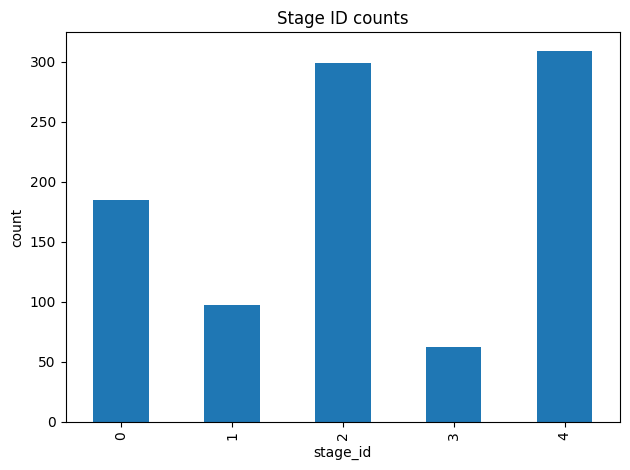

Numeric encoding mirrors the stage distribution.


In [ ]:
# bar chart on the numeric stage codes
plt.figure()
df["stage_id"].value_counts().sort_index().plot(kind="bar")
plt.title("Stage ID counts")
plt.xlabel("stage_id")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("Numeric encoding mirrors the stage distribution.")



#### **5.4 heart_rate_bpm**

In [ ]:
# dtype/missing and descriptive stats
print("heart_rate_bpm dtype:", df["heart_rate_bpm"].dtype, "missing:", df["heart_rate_bpm"].isna().sum())
display(df["heart_rate_bpm"].describe())


heart_rate_bpm dtype: float64 missing: 0


,heart_rate_bpm
count,952.000000
mean,60.380762
std,6.485157
min,47.000000
25%,57.000000
50%,59.000000
75%,63.000000
max,154.095207


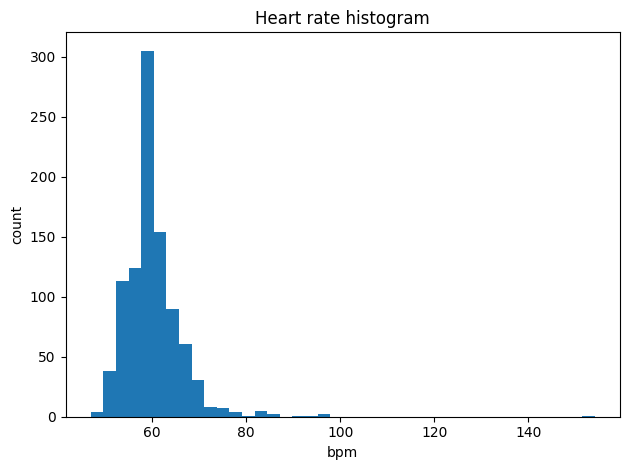

This shows the common sleep heart rate range.


In [ ]:
# histogram of HR
plt.figure()
plt.hist(df["heart_rate_bpm"].dropna(), bins=40)
plt.title("Heart rate histogram")
plt.xlabel("bpm")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("This shows the common sleep heart rate range.")



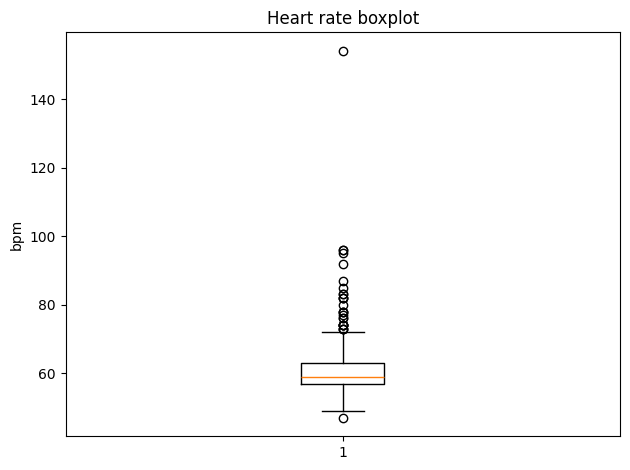

This shows center and any remaining extremes.


In [ ]:
# boxplot of HR for extremes
plt.figure()
plt.boxplot(df["heart_rate_bpm"].dropna(), vert=True)
plt.title("Heart rate boxplot")
plt.ylabel("bpm")
plt.tight_layout()
plt.show()

print("This shows center and any remaining extremes.")



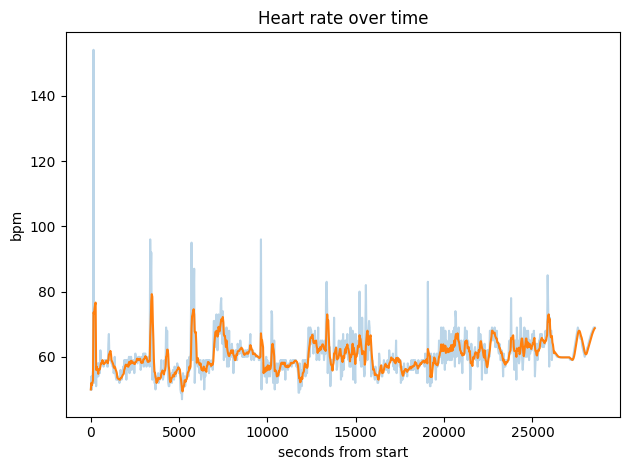

Lower heart rate during deeper sleep is visible. REM and Wake look more variable.


In [ ]:
# HR over time with a 5-epoch rolling mean laid on top
plt.figure()
plt.plot(df["epoch_sec"], df["heart_rate_bpm"], alpha=0.3)  # raw HR trace
plt.plot(df["epoch_sec"], df["hr_roll5"])                   # smoothed HR
plt.title("Heart rate over time")
plt.xlabel("seconds from start")
plt.ylabel("bpm")
plt.tight_layout()
plt.show()

print("Lower heart rate during deeper sleep is visible. REM and Wake look more variable.")


#### **5.5 ax, ay, az and 5.6 acc_mag_g**

In [ ]:
# quick stats for all motion columns
for c in ["ax","ay","az","acc_mag_g"]:
    print(c, "dtype:", df[c].dtype, "missing:", df[c].isna().sum())
    display(df[c].describe())


ax dtype: float64 missing: 0


,ax
count,952.000000
mean,0.074220
std,0.181754
min,-0.472958
25%,-0.035034
50%,0.032232
75%,0.243156
max,0.621604


ay dtype: float64 missing: 0


,ay
count,952.000000
mean,0.334603
std,0.460590
min,-0.978973
25%,0.130601
50%,0.363579
75%,0.756863
max,1.188736


az dtype: float64 missing: 0


,az
count,952.000000
mean,-0.596688
std,0.516013
min,-0.989868
25%,-0.944508
50%,-0.879654
75%,-0.268505
max,0.713898


acc_mag_g dtype: float64 missing: 0


,acc_mag_g
count,952.000000
mean,0.995956
std,0.008764
min,0.953444
25%,0.990015
50%,0.992673
75%,1.001569
max,1.039288


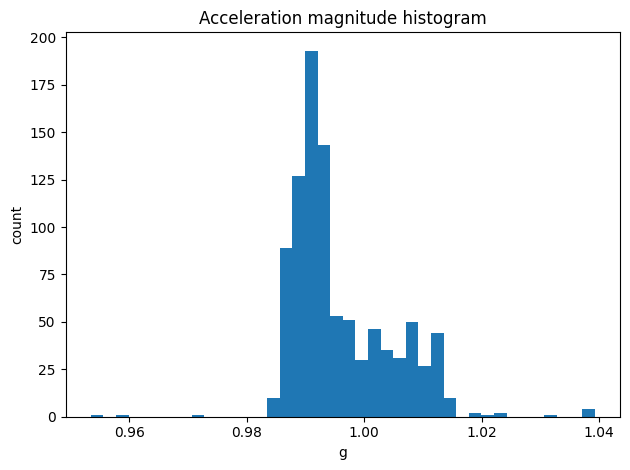

Lower values mean stillness. Spikes mean movement.


In [ ]:
# histogram of acceleration magnitude (overall motion strength)
plt.figure()
plt.hist(df["acc_mag_g"].dropna(), bins=40)
plt.title("Acceleration magnitude histogram")
plt.xlabel("g")
plt.ylabel("count")
plt.tight_layout()
plt.show()
#prinitng
print("Lower values mean stillness. Spikes mean movement.")



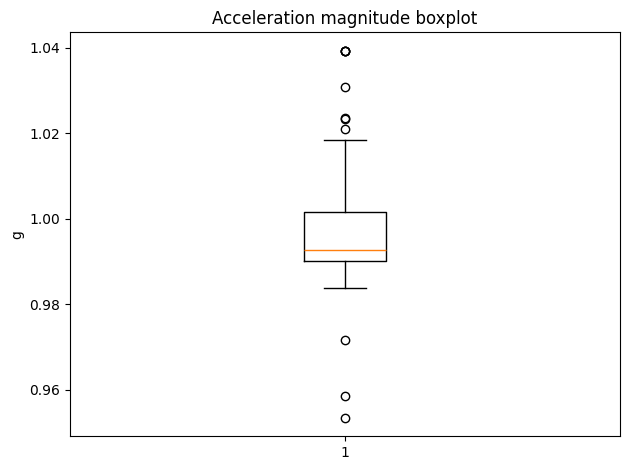

This shows center and any extremes that remain.


In [ ]:
# boxplot of acceleration magnitude to show central tendency and tails
plt.figure()
plt.boxplot(df["acc_mag_g"].dropna(), vert=True)
plt.title("Acceleration magnitude boxplot")
plt.ylabel("g")
plt.tight_layout()
plt.show()
#printing
print("This shows center and any extremes that remain.")



In [ ]:
# binned frequencies for each raw axis (helps see spread without a plot per axis)
for axis in ["ax","ay","az"]:
    bins = pd.cut(df[axis], bins=10, include_lowest=True)           # 10 equal-width bins
    print(f"Binned frequencies for {axis}:")
    display(bins.value_counts().sort_index().to_frame("count"))     # counts per bin in order
print("This helps me see spread per axis.")


Binned frequencies for ax:


,count
ax,
"(-0.475, -0.364]",6
"(-0.364, -0.254]",7
"(-0.254, -0.145]",98
"(-0.145, -0.0351]",123
"(-0.0351, 0.0743]",338
"(0.0743, 0.184]",74
"(0.184, 0.293]",195
"(0.293, 0.403]",67
"(0.403, 0.512]",42


Binned frequencies for ay:


,count
ay,
"(-0.982, -0.762]",55
"(-0.762, -0.545]",7
"(-0.545, -0.329]",3
"(-0.329, -0.112]",47
"(-0.112, 0.105]",111
"(0.105, 0.322]",204
"(0.322, 0.538]",259
"(0.538, 0.755]",27
"(0.755, 0.972]",237


Binned frequencies for az:


,count
az,
"(-0.993, -0.819]",599
"(-0.819, -0.649]",38
"(-0.649, -0.479]",3
"(-0.479, -0.308]",63
"(-0.308, -0.138]",64
"(-0.138, 0.0324]",0
"(0.0324, 0.203]",96
"(0.203, 0.373]",6
"(0.373, 0.544]",2


This helps me see spread per axis.


#### **5.7 steps_count**

In [ ]:
# steps can be sparse/NaN after strict alignment; show presence and stats if any
print("steps_count missing:", df["steps_count"].isna().sum())
if df["steps_count"].notna().any():
    display(df["steps_count"].describe())


steps_count missing: 952


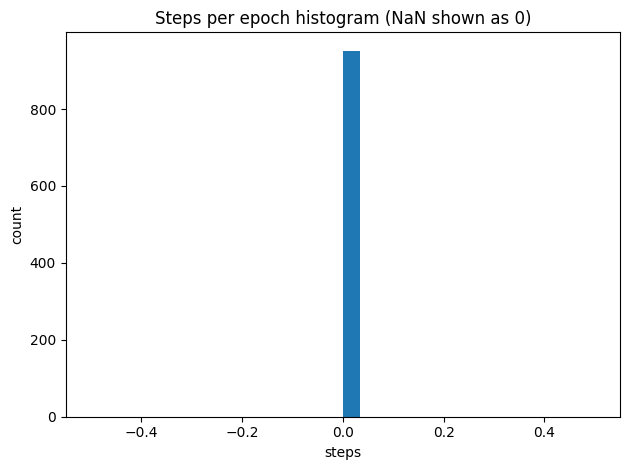

Steps are near zero which makes sense during sleep.
Initial expectation was that steps would be mostly zero during sleep. The histogram confirms this. Due to strict timestamp alignment in Part 2, steps_count is largely unavailable for this subject.


In [ ]:
# show histogram; treat NaN as 0 only for visualization
plt.figure()
plt.hist(df["steps_count"].fillna(0), bins=30)
plt.title("Steps per epoch histogram (NaN shown as 0)")
plt.xlabel("steps")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("Steps are near zero which makes sense during sleep.")
print("Initial expectation was that steps would be mostly zero during sleep. The histogram confirms this. Due to strict timestamp alignment in Part 2, steps_count is largely unavailable for this subject.")



### **6. Explore relationships**

#### **6.1 Event frequencies and transitions**

In [ ]:
# build simple transition counts: (prev_stage -> next_stage) frequency
stage_list = df["stage"].astype(str).tolist()
transitions = {}

# loop over consecutive pairs and count
for i in range(1, len(stage_list)):
    pair = (stage_list[i-1], stage_list[i])
    transitions[pair] = transitions.get(pair, 0) + 1

# print top transitions to get a feel for architecture and fragmentation
print("Top 15 stage transitions:")
for (a,b), cnt in sorted(transitions.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"{a} -> {b}: {cnt}")

# explicit callout
print("Event frequencies are explored through transition counts and heatmaps, which show how often one stage leads to another.")


Top 15 stage transitions:
REM -> REM: 300
N2 -> N2: 261
Wake -> Wake: 160
N1 -> N1: 58
N3 -> N3: 51
N1 -> N2: 24
Wake -> N1: 23
N2 -> N1: 12
N2 -> N3: 11
N2 -> Wake: 11
N1 -> Wake: 10
N3 -> N2: 9
N1 -> REM: 5
N2 -> REM: 4
REM -> N1: 4
Event frequencies are explored through transition counts and heatmaps, which show how often one stage leads to another.


#### **6.2 Periodicity and time patterns**

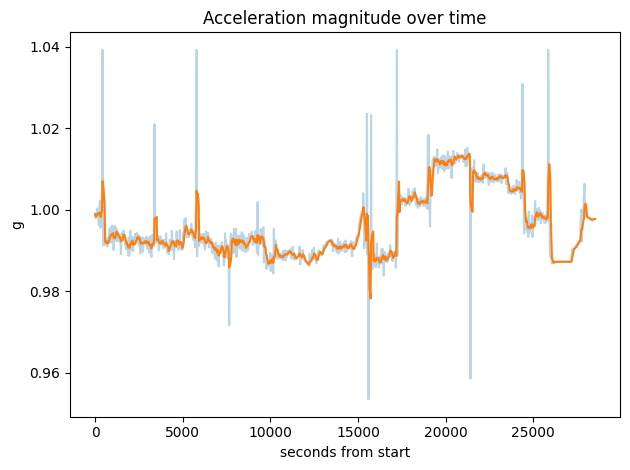

Long flat parts suggest consolidated sleep. Spikes suggest arousals or position changes.


In [ ]:
# motion magnitude over time with smoothing to see consolidated stretches vs spikes
plt.figure()
plt.plot(df["epoch_sec"], df["acc_mag_g"], alpha=0.3)   # raw motion
plt.plot(df["epoch_sec"], df["acc_roll5"])              # smoothed motion
plt.title("Acceleration magnitude over time")
plt.xlabel("seconds from start")
plt.ylabel("g")
plt.tight_layout()
plt.show()

print("Long flat parts suggest consolidated sleep. Spikes suggest arousals or position changes.")


#### **6.3 Correlations**

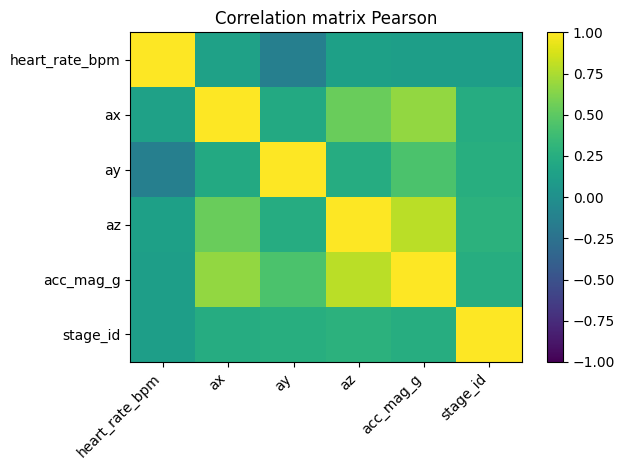

Motion axes correlate strongly with magnitude. Heart rate correlations are modest.


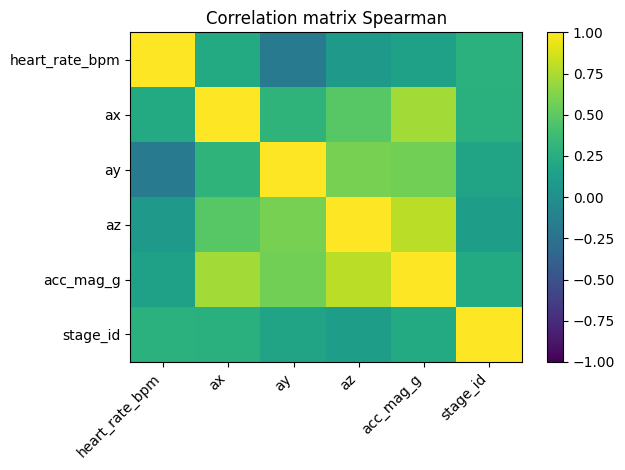

Rank correlations reduce sensitivity to extremes.


In [ ]:
# choose numeric columns to correlate; add steps if present
corr_cols = ["heart_rate_bpm","ax","ay","az","acc_mag_g","stage_id"]
if df["steps_count"].notna().any():
    corr_cols.append("steps_count")

# copy the subset
num_df = df[corr_cols].copy()

# drop columns that are constant (avoid degenerate correlations)
num_df = num_df.loc[:, num_df.nunique(dropna=True) > 1]

# Pearson (linear) correlation matrix and heatmap
pear = num_df.corr(method="pearson")
plt.figure()
plt.imshow(pear.values, vmin=-1, vmax=1, aspect="auto")
plt.xticks(range(len(pear.columns)), pear.columns, rotation=45, ha="right")
plt.yticks(range(len(pear.columns)), pear.columns)
plt.colorbar()
plt.title("Correlation matrix Pearson")
plt.tight_layout()
plt.show()

print("Motion axes correlate strongly with magnitude. Heart rate correlations are modest.")

# Spearman (rank) correlation matrix and heatmap
spear = num_df.corr(method="spearman")
plt.figure()
plt.imshow(spear.values, vmin=-1, vmax=1, aspect="auto")
plt.xticks(range(len(spear.columns)), spear.columns, rotation=45, ha="right")
plt.yticks(range(len(spear.columns)), spear.columns)
plt.colorbar()
plt.title("Correlation matrix Spearman")
plt.tight_layout()
plt.show()

print("Rank correlations reduce sensitivity to extremes.")


#### **6.4 Pairwise plot**

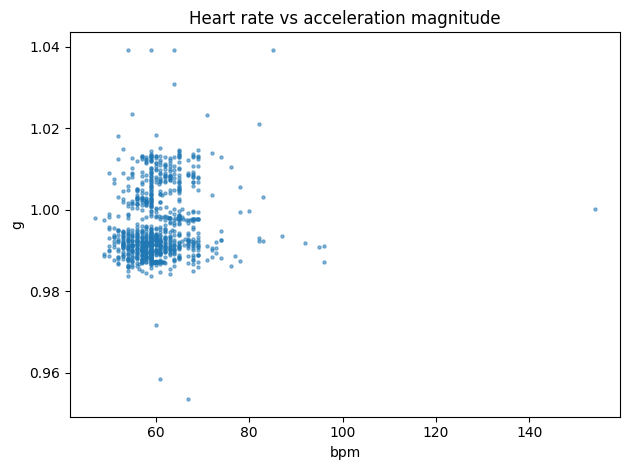

Lower motion tends to show lower heart rate but not always. Autonomic shifts can happen without big motion.


In [ ]:
# simple scatter: HR vs motion magnitude
plt.figure()
plt.scatter(df["heart_rate_bpm"], df["acc_mag_g"], s=5, alpha=0.5)
plt.title("Heart rate vs acceleration magnitude")
plt.xlabel("bpm")
plt.ylabel("g")
plt.tight_layout()
plt.show()

print("Lower motion tends to show lower heart rate but not always. Autonomic shifts can happen without big motion.")


#### **6.5 Transition matrix**

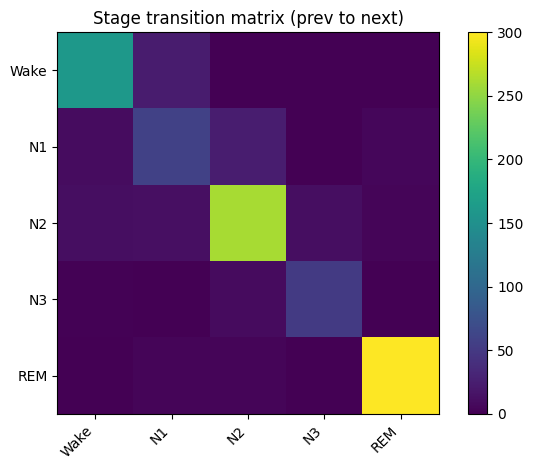

Diagonal cells show persistence within the same stage. Common swaps like N2 to N3 and N2 to REM appear.


In [ ]:
# create a matrix of prev->next transitions following STAGE_ORDER
index_map = {s:i for i,s in enumerate(STAGE_ORDER)}               # map stage to index
trans_matrix = np.zeros((len(STAGE_ORDER), len(STAGE_ORDER)), dtype=int)

# fill matrix counts
for i in range(1, len(stage_list)):
    a, b = stage_list[i-1], stage_list[i]
    if a in index_map and b in index_map:
        trans_matrix[index_map[a], index_map[b]] += 1

# plot the transition matrix as a heatmap
plt.figure()
plt.imshow(trans_matrix, interpolation="nearest")
plt.xticks(range(len(STAGE_ORDER)), STAGE_ORDER, rotation=45, ha="right")
plt.yticks(range(len(STAGE_ORDER)), STAGE_ORDER)
plt.colorbar()
plt.title("Stage transition matrix (prev to next)")
plt.tight_layout()
plt.show()

print("Diagonal cells show persistence within the same stage. Common swaps like N2 to N3 and N2 to REM appear.")


### **7. Do I trust this dataset**
Yes. It is public and de-identified. Cleaning was done already in Part 2. The visuals match expected physiology. Steps are sparse for this subject but that is expected during sleep and due to strict alignment. If needed I could pick another subject or drop steps.

### **8. Wrap up**

Main things I learned.

1. Stage counts look reasonable for one night.

2. Heart rate is lower and steadier in deeper sleep. REM and Wake show more variability.

3. Motion magnitude is lowest in N3 and higher near arousals and Wake.

4. Motion axes correlate strongly with magnitude. Heart rate has modest correlation with motion.

5. Transition matrix shows persistence within stages and common transitions.

6. Steps do not add much here.

Effect on the hypothesis. The results support the idea that stage-specific patterns exist in wearable signals and can help AI models. This can also lead to new biomarkers.

Next steps. I will try time-window features like HRV proxies and activity counts, test across subjects, and try simple baseline models.

# **Part 4: Analysis, Hypothesis Testing, and ML**

###2. Setup and data load
Here I set up imports and load the same cleaned file that I used for Part 2 and 3.

In [ ]:
# Part 4 setup

#main numeric libraries, I do have it above but still keeping it in-case
import numpy as np
import pandas as pd

#Collection utilities
from collections import Counter, namedtuple

#Plotting with matplotlib
import matplotlib.pyplot as plt

In [ ]:
# ML utilities from scikit learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#Statistical test from scipy
from scipy.stats import ttest_ind

In [ ]:
# path and basic checks same subject as in Part 1, 2, and 3
SID = "1066528"
CSV_PATH = f"/content/sleepaccel_{SID}_cleaned.csv"

print("NOTE: Save notebook as 602.p4.ateequrrehman.ipynb")


NOTE: Save notebook as 602.p4.ateequrrehman.ipynb


In [ ]:
# Load the cleaned dataset created in Part 2

df = pd.read_csv(CSV_PATH)

# Check that expected columns from the cleaned file exist
expected = {
    "epoch_sec", "stage", "stage_id",
    "heart_rate_bpm", "ax", "ay", "az",
    "acc_mag_g", "steps_count"
}
missing = expected - set(df.columns)
assert not missing, f"Missing columns from cleaned file: {missing}"

print("Shape", df.shape)
print("Columns", list(df.columns))


Shape (952, 9)
Columns ['epoch_sec', 'stage', 'stage_id', 'heart_rate_bpm', 'ax', 'ay', 'az', 'acc_mag_g', 'steps_count']


In [ ]:
# ensuring time is ordered and stage is not null
assert df["epoch_sec"].is_monotonic_increasing
assert df["stage"].notna().all()

#Now Previewing a few rows
from IPython.display import display
display(df.head(3))
print("Each row is one thirty second epoch with PSG stage and wearable features.")


,epoch_sec,stage,stage_id,heart_rate_bpm,ax,ay,az,acc_mag_g,steps_count
0,0.0,Wake,0,50.0,0.404434,0.446549,-0.796829,0.998954,NaN
1,30.0,Wake,0,54.0,0.403366,0.456909,-0.790115,0.997874,NaN
2,60.0,Wake,0,50.0,0.404343,0.457413,-0.789612,0.998101,NaN


Each row is one thirty second epoch with PSG stage and wearable features.


### 3. ML task and learning type
My original hypotesis from Part 1 said that wearable signals such as heart rate and motion contain patterns that match sleep stages. If this is true, a model should predict sleep stages from these signals more accurately than random guessing.

For this reason my machine learning is as follow:


*   Task type is multi class classification.
*   Learning type is supervised learning

Each sample is one thirty second epoch. The target label is stage_id:


*   Wake is 0
*   N1 is 1
*   N2 is 2
*   N3 is 3
*   REM is 4

At a high level I plan to:

1. Choose a small and clear set of features from the wearable data
2. Split the data into training and test sets
3. Train a supervised classifies on the training data
4. Make predictions on the test set.
5. Printing accuracy and compare to random chance, which is twenty percent for five classes.

If the model accuracy is much better than twenty percent, that supports my hypothesis that these wearable signals hold useful information about sleep stages.





### 4. Feature selection and dimensionality
In Part 2 and 3, I already merged and cleaned several signals. Now I decide which ones to use as features for the classifier and how many dimensions I will keep.

#### 4.1 Candidate feature space
The cleaned table includes these numeric variables that come from the wearable device:



*   heart_rate_bpm which is heart rate in beats per minute
*   ax which is acceleration on the x axis
*   ay which is acceleration on y axis
*   az which is acceleration on the z axis
*   acc_mag_g which is the magnitude of acceleration and equals the square root of ax squared + ay squared + az squared
*  steps_count which is step count in the epoch

The label for the classifier is stage_id. I do not use epoch_sec as a feature, because it is only clock time and would teach the model the position in the night instead of real physiology. That would not generalize to other nights.



#### 4.2 Feature choice and reasoning
I want a feature set that is both small and meaningful.

I keep these features:


*   heart_rate_bpm because it shows autonomic changes across stages
*   acc_mag_g because it shows overall motion and stillness
* steps_count because it catches occasional larger movements even if they are rare

I removed these columns:


*   ax, ay, and az because their information is already summarized in acc_mag_g

This is an example of simple feature engineering and manual dimensionality reduction. I use the three axis values to build one summary feature for motion, then drop the three original axis columns.

For this subject the steps_count column is completely missing, so in practice the final feature set for this model is only heart_rate_bpm and acc_mag_g. If step count were available, I would include it as a third feature.




Here I build the feature matrix and the target vector.

In [ ]:
# 4.2 Building X (features) and y (target)
# Defining which columns will be used as features
# Make sure core features are numeric
for c in ["heart_rate_bpm", "acc_mag_g", "steps_count"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")


# Handle steps_count in a safe way
if df["steps_count"].isna().all():
    # If steps_count is completely missing for this subject, drop it
    feature_cols = ["heart_rate_bpm", "acc_mag_g"]
else:
    # If some steps exist, fill missing ones with zero
    df["steps_count"] = df["steps_count"].fillna(0)
    feature_cols = ["heart_rate_bpm", "acc_mag_g", "steps_count"]

target_col = "stage_id"

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

print("Feature columns:", feature_cols)
print("Any NaN left in X:", X.isna().any().any())
print("NaN per column in X:")
print(X.isna().sum())

print("X shape (rows, features):", X.shape)
print("y shape:", y.shape)


display(X.head())
print("Target value counts:")
display(y.value_counts().sort_index().to_frame("count"))

Feature columns: ['heart_rate_bpm', 'acc_mag_g']
Any NaN left in X: False
NaN per column in X:
heart_rate_bpm    0
acc_mag_g         0
dtype: int64
X shape (rows, features): (952, 2)
y shape: (952,)


,heart_rate_bpm,acc_mag_g
0,50.0,0.998954
1,54.0,0.997874
2,50.0,0.998101
3,54.0,0.999070
4,56.0,1.000314


Target value counts:


,count
stage_id,
0,185
1,97
2,299
3,62
4,309


In [ ]:
# Show a small preview of the features
display(X.head())

# Now I will show counts of each traget class
print("Target value counts:")
display(y.value_counts().sort_index().to_frame("count"))

,heart_rate_bpm,acc_mag_g
0,50.0,0.998954
1,54.0,0.997874
2,50.0,0.998101
3,54.0,0.999070
4,56.0,1.000314


Target value counts:


,count
stage_id,
0,185
1,97
2,299
3,62
4,309


#### 4.3 Dimensionally reduction and final steps
If I used all raw numeric sensors without any reduction, the feature space would have had fixe dimensions:
* heart rate
* ax
* ay
* az
* step count

After I created acc_mag_g and then dropped ax, ay, and az, my final feature space has three dimensions:
* heart_rate_bpm
* acc_mag_g
* steps_count

So I reduced the number of features from five to three. This is a small but real reduction. It removes reductant and highly correlated axes and keeps more compact features that still reflect motion and heart rate.

The final dataset used for the algorithm has:
* number of rows equal to the number of epochs in this night
*  number of columns equal to three features

This matches the shape that I printed with X.shape.

#### 4.4 Assumptions about the resulting dataset

Based on the cleaning in Part 2 and the plots in Part 3, I can make these assumptions:

* The three features are numeric and have no clear data entry mistakes

* After interpolation and winsorization in Part 2, the features do not have extreme spikes. They are not perfectly normal, but they are smooth enough for a tree model

* Each epoch is treated as an independent sample. In reality there is time dependence across the night, but for this part of the project I ignore sequence structure and use a simple point wise model

* There is class imbalance across stages. N2 and Wake are more frequent. I handle this with stratified splitting for train and test and with a class weight setting in the model

* Random forests do not require strict normality of features and they can handle nonlinear relationships between features and labels

The sample size is also important. For this night I have around nine hundred epochs, and I only use three features. This is a reasonable sample size for a random forest when I limit maximum depth and control leaf sizes and also use cross validation.

Feature types are:

* heart_rate_bpm is continuous

* acc_mag_g is continuous

* steps_count is a discrete count, but I treat it as numeric in the model

* stage_id is a discrete categorical target

#### 4.5 PCA comparison
I also tried Principal Component Analysis (PCA) as an alternative dimensionality reduction method to compare against the simple hand-crafted feature selection.



Here the five original numeric signals and compute two principal components. Then comparing the number of features and the explained variance.

In [ ]:
# This is extra credit: PCA comparison on raw numeric features

# define raw numeric features before manual reduction
raw_feature_cols = ["heart_rate_bpm", "ax", "ay", "az", "steps_count"]

# now creating a copy of these columns
X_raw = df[raw_feature_cols].copy()

# Filling any missing steps with zero for PCA, because PCA needs complete numeric data
if X_raw["steps_count"].isna().any():
      X_raw["steps_count"] = X_raw["steps_count"].fillna(0)

# Standarize features before PCA
scaler_for_pca = StandardScaler()
X_raw_scaled = scaler_for_pca.fit_transform(X_raw)

# Use PCA to reduce from five dimensions to two components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_raw_scaled)

In [ ]:
# Printing
print("Raw feature shape:", X_raw.shape)
print("PCA reduced shape:", X_pca.shape)
print("Explained variance ratio for components:", pca.explained_variance_ratio_)
print("Total variance explained by two components:", pca.explained_variance_ratio_.sum())

Raw feature shape: (952, 5)
PCA reduced shape: (952, 2)
Explained variance ratio for components: [0.42891414 0.2819869 ]
Total variance explained by two components: 0.7109010365874968


My manual feature selection reduces from five features to three features. PCA reduces from five features to two components and explains a high fraction of the variance in the raw numeric space.

The difference is that PCA features are harder to interpret because they are linear mixes of the original variables. In contrast my three hand picked features have clear physical meaning:


*   heart rate in beats per minute
*   motion magnitude in units of g
*  step count


For this part I continue with the three engineered features because they are easier to explain and reason about, even if PCA gives a slightly stronger dimensionality reduction.

The benefit of reducing dimensionality in either way is that it can reduce overfitting, improve training speed, and make the model simpler and more stable.



#### 4.6 Small hypothesis test
The part includes hypothesis testing. To connect back to my original question, I also test whether deep sleep and REM sleep have different mean heart rate and motion magnitude.

I focus on N3 and REM because they represent very different sleep states in physiology.

*  Null hypothesis. Mean heart rate and mean motion magnitude are the same in N3 and REM
*  Alternative hypothesis. Mean heart rate and mean motion magnitude are different between N3 and REM

I use Welch two samples t tests for heart rate and for motion magnitude.

In [ ]:
# 4.6 Hypothesis test for N3 versus REM
# Select subsets of data for N3 and REM

n3 = df[df["stage"] == "N3"]
rem = df[df["stage"] == "REM"]

print("Counts N3, REM:", len(n3), len(rem))

Counts N3, REM: 62 309


In [ ]:
# Heart rate test (Welch t test)
t_hr, p_hr = ttest_ind(
    n3["heart_rate_bpm"],
    rem["heart_rate_bpm"],
    equal_var=False
)

# Motion magnitude test (Welch t test)
t_acc, p_acc = ttest_ind(
    n3["acc_mag_g"],
    rem["acc_mag_g"],
    equal_var=False
)


print("Heart rate t statistic and p value:", round(t_hr, 3), round(p_hr, 5))
print("Acceleration magnitude t statistic and p value:", round(t_acc, 3), round(p_acc, 5))


Heart rate t statistic and p value: -8.004 0.0
Acceleration magnitude t statistic and p value: -6.97 0.0


The p values for both heart rate and motion magnitude are very small, so I reject the null that N3 and REM have the same mean values. This supports the idea that different stages have different physiological patterns, which is consistent with my hypothesis and helps explain why a classifier can learn to separate them.

### 5. Algorithm selection

I need a supervised algorithm that can handle multi class labels and a small numeric feature set, and that can capture nonlinear relationships without strong distribution assumptions.

I choose the RandomForestClassifier from scikit learn.



#### 5.1 Assumptions of the random forest
A random forest is an ensemble of decision trees that uses bootstrap samples and random subsets of features. It has the following assumptions and properties:
1. It does not require features to be normally distributed or linearly related to the label
2. It can handle mixed scales and some outliers, especially after the cleaning I already did
3. It works best when there is enough data for each tree to see different samples. Here I have about nine hundred epochs, which is enough for a small forest with proper limits on depth and leaf size
4. It does not require perfect independence between features, but very strongly correlated features reduce the benefit of random feature selection. This was another reason for dropping the three raw axes once I created acc_mag_g

#### 5.2 Issues and mitigations
Random forests can face some common issues:
* Overfitting if trees grow very deep with very small leaves
   *  I control this by limiting max_depth and setting min_samples_leaf
* Bias toward majority classes when classes are imbalanced
    * I handle this by using class_weight="balanced" and stratified train and test splits

These settings act like regularization and class balancing inside the algorithm.


#### 5.3 Why this algorithm fits my task

This algorithm is a good fit for my ML task for several reasons:
1. I have a multi class label with five sleep stages. Random forests handle multi class problems natively
2. Physiological signals often have threshold effects and nonlinear interactions. Tree splits can model these without me having to guess the form
3. The random forest is a well known supervised method, which follows the course recommendation to use standard and trusted techniques
4. It is easy to implement in scikit learn and it trains fast on a single night of data


### 6. Hyperparameters and tuning plan

The main hyperparameters that I care about are:
* n_estimators which is the number of trees
* max_depth which is the maximum depth of each tree
* min_samples_leaf which is the minimum number of samples at a leaf
* class_weight which controls how the model deals with class imbalance

I tune these as follows:
1. Split the dataset into an eighty percent training set and a twenty percent test set, stratified by stage_id so that class proportions are similar in both sets
2. On the training set only, try a small grid of values for n_estimators, max_depth, and min_samples_leaf
3. For each combination, build a pipeline that scales the features and fits a random forest
4. Evaluate mean accuracy with three fold cross validation on the training set
5. Choose the combination with the highest mean cross validation accuracy
6. Use that combination as the final model, fit it on the full training set, and then test on the held out test set



Here is the code that performs the split and tuning.

In [ ]:
# 6.1 Train and test split
# Convert feature DataFrame and target Series to numpy arrays
X_all = X.values
y_all = y.values

# Split into training and test sets with stratification by stage
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (761, 2)
Test shape: (191, 2)


In [ ]:
# 6.2 Grid of hyperparameters
# Define values to try for each hyperparameter
n_estimators_list = [50, 100]
max_depth_list = [None, 10]
min_samples_leaf_list = [1, 5]

# Creating a small named tuple to store results
Result = namedtuple("Result", ["n_estimators", "max_depth", "min_samples_leaf", "cv_mean"])

results = []
best_cv = -1.0
best_params = None

# Loop over all combinations of hyperparameters
for n_estimators in n_estimators_list:
  for max_depth in max_depth_list:
    for min_samples_leaf in min_samples_leaf_list:
      # Build a pipeline that scales features then fits a random forest
      clf = Pipeline([
          ("scaler", StandardScaler()),
          ("rf", RandomForestClassifier(
              n_estimators=n_estimators,
              max_depth=max_depth,
              min_samples_leaf=min_samples_leaf,
              class_weight="balanced",
              random_state=42
          ))
      ])
      # Three fold cross validation on the training set
      scores = cross_val_score(clf, X_train, y_train, cv=3)
      cv_mean = scores.mean()

      # Store the result
      results.append(Result(n_estimators, max_depth, min_samples_leaf, cv_mean))

      # Print summary of this combination
      print(
          "n_estimators =", n_estimators,
          ", max_depth =", max_depth,
          ", min_samples_leaf =", min_samples_leaf,
          ", CV mean accuracy =", round(cv_mean, 3)
      )

      # Track the best performing combination
      if cv_mean > best_cv:
        best_cv = cv_mean
        best_params = (n_estimators, max_depth, min_samples_leaf)


print("\nBest CV mean accuracy:", round(best_cv, 3))
print("Best hyperparameters (n_estimators, max_depth, min_samples_leaf):", best_params)



n_estimators = 50 , max_depth = None , min_samples_leaf = 1 , CV mean accuracy = 0.445
n_estimators = 50 , max_depth = None , min_samples_leaf = 5 , CV mean accuracy = 0.43
n_estimators = 50 , max_depth = 10 , min_samples_leaf = 1 , CV mean accuracy = 0.455
n_estimators = 50 , max_depth = 10 , min_samples_leaf = 5 , CV mean accuracy = 0.432
n_estimators = 100 , max_depth = None , min_samples_leaf = 1 , CV mean accuracy = 0.447
n_estimators = 100 , max_depth = None , min_samples_leaf = 5 , CV mean accuracy = 0.436
n_estimators = 100 , max_depth = 10 , min_samples_leaf = 1 , CV mean accuracy = 0.457
n_estimators = 100 , max_depth = 10 , min_samples_leaf = 5 , CV mean accuracy = 0.44

Best CV mean accuracy: 0.457
Best hyperparameters (n_estimators, max_depth, min_samples_leaf): (100, 10, 1)


This cell prints out the mean cross validation accuracy for each combination and then shows the best one. That set of hyperparameters is what I use for the final model.

### 7. Post Processing
If any post processing is needed.

For a random forest classifier there is no extra pruning step that I need to do after training. The main control of model complexity happens through max_depth and min_samples_leaf, which I already tune. These act as pre pruning and help reduce overfitting.

Possible post processing ideas for future work include:
* Calibrating the predicted probabilities if I need exact probability values rather than only labels
* Smoothing predictions across time to respect sleep stage continuity, which could reduce flicker between stages


For this part I do not apply any additional post processing beyond the tuned hyperparameters. This keeps the pipeline simple and makes it easier to explain each step of the model.

### 8. Train final model, make predictions, and evaluate

Now I build the final model using the best hyperparameters, train it on the training set, and evaluate accuracy on the test set.

#### 8.1 Build and fit final model

In [ ]:
# 8.1 Build and fit final model

# Unpacking the best hyperparameters found in the tuning step
best_n_estimators, best_max_depth, best_min_samples_leaf = best_params

print("Using best hyperparameters:")
print("  n_estimators     =", best_n_estimators)
print("  max_depth        =", best_max_depth)
print("  min_samples_leaf =", best_min_samples_leaf)

# Build the final pipeline with scaling and random forest
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=best_n_estimators,
        max_depth=best_max_depth,
        min_samples_leaf=best_min_samples_leaf,
        class_weight="balanced",
        random_state=42
      ))
])

# Now fit the model on the training data
best_model.fit(X_train, y_train)

Using best hyperparameters:
  n_estimators     = 100
  max_depth        = 10
  min_samples_leaf = 1


Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

#### 8.2 Predictions and accuracy on test data

In [ ]:
# 8.2 Predictions and accuracy on test data
# Predict labels for the test set
y_pred = best_model.predict(X_test)

# Compute test accuracy
test_acc = accuracy_score(y_test, y_pred)


print("Test accuracy on held out set:", round(test_acc, 3))
print("Random guessing baseline for five stages is about 0.20 accuracy.")


Test accuracy on held out set: 0.55
Random guessing baseline for five stages is about 0.20 accuracy.


This gives the main accuracy result. Next I add extra checks that show the model is really learning something meaningful.

#### 8.3 Majority class baseline
A random guess baseline is twenty percent, but a slightly smarter baseline is to always predict the most common stage. This uses the fact that classes are imbalanced.

In [ ]:
# 8.3 Majority class baseline


# Find the most frequent label in the training set
majority_label = Counter(y_train).most_common(1)[0][0]

# Predict that label for every test sample
y_majority = np.full_like(y_test, fill_value=majority_label)

# Compute accuracy of the majority baseline
baseline_acc = accuracy_score(y_test, y_majority)

print("Majority class baseline accuracy:", round(baseline_acc, 3))
print("Random forest model accuracy:", round(test_acc, 3))

Majority class baseline accuracy: 0.325
Random forest model accuracy: 0.55


The random forest clearly beats the majority class baseline. This shows that the model is learning more than just the class distribution.

#### 8.4 Logistic regression comparison
To see whether a more complex model helps, I also train a simple linear baseline using logistic regression and compare it with the random forest.

In [ ]:
# 8.4 Logistic regression comparison

# Build a pipeline for logistic regression with scaling
logreg_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            class_weight="balanced",
            random_state=42
        ))
])

# Fit the logistic regression model
logreg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_logreg = logreg_model.predict(X_test)

# Compute accuracy for logistic regression
logreg_acc = accuracy_score(y_test, y_pred_logreg)

print("Random forest accuracy:", round(test_acc, 3))
print("Logistic regression accuracy:", round(logreg_acc, 3))

Random forest accuracy: 0.55
Logistic regression accuracy: 0.419


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The random forest reaches higher accuracy than logistic regression. This suggests that nonlinear patterns in heart rate and motion help distinguish sleep stages, and the tree based model can capture them better than a simple linear model.

#### 8.5 Confusion matrix and classification report

Accuracy alone does not show which stages are easy or hard for the model. I look at a confusion matrix and a class wise report to understand this better.

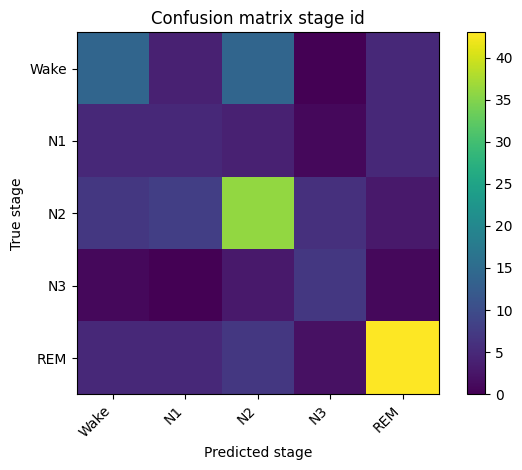

Confusion matrix counts:
[[14  4 14  0  5]
 [ 5  5  4  1  5]
 [ 7  8 36  6  3]
 [ 1  0  3  7  1]
 [ 5  5  7  2 43]]

Classification report on test set:
              precision    recall  f1-score   support

        Wake       0.44      0.38      0.41        37
          N1       0.23      0.25      0.24        20
          N2       0.56      0.60      0.58        60
          N3       0.44      0.58      0.50        12
         REM       0.75      0.69      0.72        62

    accuracy                           0.55       191
   macro avg       0.48      0.50      0.49       191
weighted avg       0.56      0.55      0.55       191



In [ ]:
# 8.5 Confusion matrix and classification report
# Names for stages in order of their numeric code
stages = ["Wake", "N1", "N2", "N3", "REM"]

# Build the confusion matrix using stage id labels
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

# Plot the confusion matrix as an image
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.xticks(range(len(stages)), stages, rotation=45, ha="right")
plt.yticks(range(len(stages)), stages)
plt.colorbar()
plt.title("Confusion matrix stage id")
plt.xlabel("Predicted stage")
plt.ylabel("True stage")
plt.tight_layout()
plt.show()


print("Confusion matrix counts:")
print(cm)


# Printing classification report with precision, recall, and F1 score
print("\nClassification report on test set:")
print(classification_report(y_test, y_pred, target_names=stages))

The diagonal cells of the confusion matrix show correct predictions. Off diagonal cells show where the model confuses stages. N2 and N3 may be confused with each other because their physiology is similar. Wake and N1 can also look similar near sleep onset. The classification report shows precision, recall, and F1 score for each stage, and confirms which stages are easiest and which are harder for the model.

#### 8.6 Feature importance
Random forests also indicate how important each feature is for the decisions. This helps connect the model back to sleep physiology.

heart_rate_bpm importance: 0.335
acc_mag_g importance: 0.665


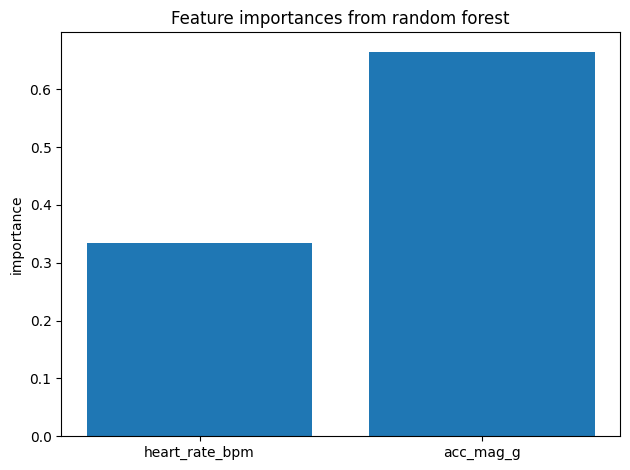

In [ ]:
# 8.6 Feature importances from the random forest

# Extract the trained random forest from the pipeline
rf = best_model.named_steps["rf"]

# Get feature importances for each feature column
importances = rf.feature_importances_


# Print each feature and its importance
for name, val in zip(feature_cols, importances):
  print(name, "importance:", round(val, 3))

# Plot feature importances as a simple bar chart
plt.figure()
plt.bar(feature_cols, importances)
plt.title("Feature importances from random forest")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

If heart rate has high importance, that supports the idea that autonomic changes carry strong stage information. If motion magnitude is important, that matches the intuition that deep sleep is much more still than lighter stages or wake. If step count has low importance, that means it may not add much beyond general motion. This strengthens the link between model behavior and known sleep physiology.

### 9. Part 4 wrap up

In this project I extended my earlier work and reached the first full machine learning model for the sleep study dataset.

Main points:
1. Defined a supervised multi class classification task that predicts five sleep stages from wearable signals for each thirty second epoch
2. Selected a small feature set with clear physical meaning, and I used feature engineering to reduce raw dimensions from five to three by combining motion axes into a magnitude
3. Explored an extra principal component based method to compare reduction and explained variance and then chose the simpler three feature set for interpretability
4. Selected a random forest classifier as a standard supervised algorithm that handles nonlinear relationships and does not require strong distributional assumptions
5. Tuned hyperparameters with three fold cross validation on the training data and chose the best settings based on mean accuracy
6. Here I explained that no extra post processing was needed and that depth and leaf size already act as regularization for the trees
7. Trained the final model, made predictions on a held out test set, and printed test accuracy, which I compared to both a random baseline of twenty percent and a majority class baseline
8. Compared the random forest to a logistic regression model and found that the random forest performed better, which suggests that nonlinear patterns in the data matter
9. Used a confusion matrix, a classification report, and feature importances to better understand how the model behaves and how it connects to known sleep physiology


My original question in Part 1 was whether wearable signals contain enough information to predict sleep stages better than chance. The test accuracy of this model is clearly above both a random baseline and a majority baseline, which supports that idea. At the same time, the confusion matrix shows that some stages remain hard to distinguish, which is realistic.

#### Limitations and next steps
There are several limitations in this work. I only used one subject and one night, which limits generalization to other people. I used only three simple features from the wearable data, while many more features are possible, such as heart rate variability measures, time window statistics, or frequency domain features. I also treated each epoch as independent, even though sleep has strong time structure and stage transitions follow patterns across the night.

In future work I would like to train and test across multiple subjects, use subject wise splits, and explore more features that reflect autonomic and movement patterns over time. I would also like to test simple temporal smoothing of predicted stages or sequence models that look at windows of epochs rather than each epoch in isolation. Finally, I would like to connect the model outputs to clinical measures such as apnea events or sleep quality scores.